# Silicon p–n Junction Diode Simulation with DEVSIM

This notebook is an introduction to semiconductor device simulation using **DEVSIM**, an open-source Technology Computer-Aided Design (TCAD) simulator. We  explain each stage of the simulation process, connecting the underlying semiconductor physics with the numerical methods used to solve the governing equations.

Our goal is to simulate the **current–voltage (I–V) characteristics** of a silicon p–n junction solar cell. Along the way, we will examine how physical models, material properties, mesh generation, numerical discretization, and nonlinear equation solving work together to predict device behavior.

**Why Study Device Simulations?**:  Modern semiconductor devices are rarely designed by fabrication alone. Instead, engineers first create numerical models that predict device performance before a single wafer is processed.

Technology Computer-Aided Design (TCAD) enables engineers and researchers to

- understand device physics,
- optimize semiconductor structures,
- investigate new materials,
- evaluate design tradeoffs, and
- predict electrical performance before fabrication.

## Importing the Required Libraries

The first step is to import the Python libraries needed for this simulation.

- **DEVSIM** provides the semiconductor device simulator and the numerical solver used throughout the notebook.
- **NumPy** is used for numerical calculations and working with arrays.
- **Matplotlib** is used to create plots of the simulation results, such as the current–voltage (I–V) curve.
- **Pandas** is used to organize and analyze simulation data in tables.

We then display the installed **DEVSIM version** to verify which version of the simulator is being used.

Next, we import the specific DEVSIM functions needed to solve the device equations, apply voltages, and extract quantities such as carrier densities and terminal currents.

Finally, we import two helper modules:

- **`simple_physics`** contains commonly used semiconductor physics models provided with DEVSIM.
- **`diode_common`** contains reusable functions that set up the diode geometry, material properties, doping profiles, and physical equations, allowing us to focus on understanding the simulation rather than rewriting standard setup code.

In [48]:
# we begin with importing the necessary libraries

import devsim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 14

# and we can check the version of devsim we are using
print("DEVSIM version:", devsim.__version__)

DEVSIM version: 2.10.0


In [49]:
# we now import the necessary functions from devsim
from devsim import (
    get_contact_current,
    get_edge_model_values,
    get_node_model_values,
    set_parameter,
    solve,
)

import devsim.python_packages.simple_physics as simple_physics

# and the key underlying functions for a diode simulation
import diode_common

### Creating the Device

We then initialize the simulation by defining the device and region names. The code below first removes any existing device or mesh with the same name to ensure a clean start.

The function `CreateMesh()` generates the **computational mesh**, which divides the semiconductor into many small segments. Instead of solving the semiconductor equations everywhere at once, DEVSIM solves them at each point in the mesh and connects the solutions together. A finer mesh generally improves accuracy but requires more computation.

The function `SetParameters()` assigns the **material properties** of silicon needed for the simulation. These include quantities such as the permittivity, intrinsic carrier concentration, electron and hole mobilities, and temperature-dependent constants. These properties determine how electric fields form and how charge carriers move through the semiconductor.

In [50]:

device = "SiliconSolarCell"
region = "Silicon"

# Safe cleanup
if device in devsim.get_device_list():
  devsim.delete_device(device=device)

if "dio" in devsim.get_mesh_list():
    devsim.delete_mesh(mesh="dio")

diode_common.CreateMesh(
    device=device,
    region=region,
)

diode_common.SetParameters(
    device=device,
    region=region,
)


mid
bot
 (region: Silicon)
 (contact: top)
 (contact: bot)


### Visualizing the Computational Mesh

Below we plot  the **computational mesh** used to represent the one-dimensional silicon diode. Each blue marker corresponds to a **mesh node**, where DEVSIM calculates quantities such as the electrostatic potential, electron concentration, and hole concentration.

The nodes are connected internally by the simulator to form small computational elements over which the semiconductor equations are solved. Notice that the nodes are **more closely spaced near the p–n junction**, where the electric field and carrier concentrations change rapidly. Using a finer mesh in these regions improves the accuracy of the simulation while keeping the overall computation efficient.

**Plotting with Matplotlib**

The `plt` library from **Matplotlib**  is widely used for creating scientific figures. In this notebook, we use it to visualize the computational mesh and later to plot quantities such as carrier concentrations, electric potential, and the diode current–voltage (I–V) characteristics.

For more examples and the full documentation, visit:
https://matplotlib.org/stable/users/index.html

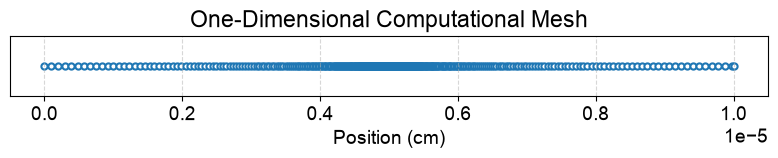

In [51]:
# Extract the x-coordinates of the mesh nodes
x = np.array(get_node_model_values(
    device=device,
    region=region,
    name="x"
))

# Plot the computational mesh
plt.figure(figsize=(8, 1.8))
plt.scatter(
    x,
    np.zeros_like(x),
    s=20,
    facecolors="white",
    edgecolors="tab:blue",
    linewidths=1.5
)
plt.yticks([])
plt.xlabel("Position (cm)")
plt.title("One-Dimensional Computational Mesh")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Defining the Physical Properties of the Diode

We next complete the physical description of the silicon diode by specifying two important quantities: the **carrier lifetimes** (`taun` and `taup`) and the **doping profile**.

The carrier lifetimes determine how long **electrons** (`taun`) and **holes** (`taup`) exist before they recombine. These parameters influence how efficiently charge carriers can travel through the device and therefore affect the diode current.

We then define the **net doping profile**, which specifies the spatial distribution of donor and acceptor atoms. This creates the p-type and n-type regions that form the p–n junction and generate the built-in electric field responsible for diode operation.

Finally, we extract the doping profile from the simulation and plot it as a function of position. This allows us to verify that the p–n junction has been defined correctly before solving the semiconductor transport equations.

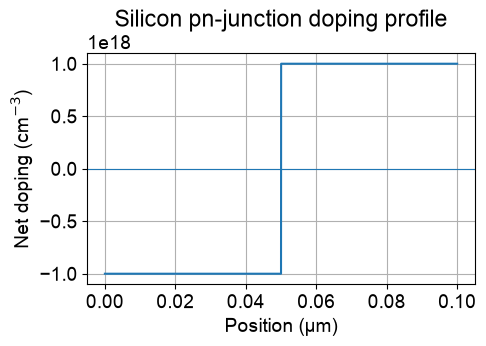

In [52]:
set_parameter(
    device=device,
    region=region,
    name="taun",
    value=1e-3,
)

set_parameter(
    device=device,
    region=region,
    name="taup",
    value=1e-3,
)
diode_common.SetNetDoping(
    device=device,
    region=region,
)
x_cm = np.asarray(
    get_node_model_values(
        device=device,
        region=region,
        name="x",
    )
)

net_doping = np.asarray(
    get_node_model_values(
        device=device,
        region=region,
        name="NetDoping",
    )
)

x_um = x_cm * 1e4

plt.figure(figsize=(5, 3))
plt.plot(x_um, net_doping)
plt.axhline(0, linewidth=0.8)
plt.xlabel("Position (µm)")
plt.ylabel("Net doping (cm$^{-3}$)")
plt.title("Silicon pn-junction doping profile")
plt.grid(True)
plt.show()

### Solving Poisson’s Equation at Equilibrium

We now compute the **electrostatic equilibrium** of the diode by solving **Poisson’s equation**. This is the first major physics solution in the notebook, and it gives us the built-in potential and depletion region that form naturally at the p–n junction before any external bias is applied.

For a semiconductor, Poisson’s equation is

$$
\nabla \cdot (\epsilon \nabla \phi) = -\rho
$$

where:

- $\phi$ is the **electrostatic potential**,
- $\epsilon$ is the **permittivity** of silicon,
- $\rho$ is the **net charge density** inside the device.

The charge density is calculated from the mobile carriers and the ionized dopants:

$$
\rho = q\,(p - n + N_D^+ - N_A^-)
$$

where:

- $q$ is the elementary charge,
- $n$ is the **electron concentration**,
- $p$ is the **hole concentration**,
- $N_D^+$ is the concentration of **ionized donor atoms**,
- $N_A^-$ is the concentration of **ionized acceptor atoms**.

This means that electrons and acceptors contribute **negative charge**, while holes and donors contribute **positive charge**. In a p–n junction, the spatial imbalance between these charges is what creates the built-in electric field.

The call to `InitialSolution()` sets up the potential-only problem and applies the contact boundary conditions, while `solve()` finds the equilibrium solution using a Newton-type iterative method. The solver settings control convergence:

- `absolute_error` sets the allowed absolute residual,
- `relative_error` sets the allowed residual relative to the problem size,
- `maximum_iterations` limits the number of Newton steps.

This equilibrium solution becomes the starting point for the full drift–diffusion simulation that follows.

In [53]:
diode_common.InitialSolution(
    device=device,
    region=region,
)

solve(
    type="dc",
    absolute_error=1.0,
    relative_error=1e-10,
    maximum_iterations=50,
)

number of equations 465
Iteration: 0
  Device: "SiliconSolarCell"	RelError: 1.00000e+00	AbsError: 8.88882e-02
    Region: "Silicon"	RelError: 1.00000e+00	AbsError: 8.88882e-02
      Equation: "PotentialEquation"	RelError: 1.00000e+00	AbsError: 8.88882e-02
Iteration: 1
  Device: "SiliconSolarCell"	RelError: 4.91285e-01	AbsError: 8.58427e-02
    Region: "Silicon"	RelError: 4.91285e-01	AbsError: 8.58427e-02
      Equation: "PotentialEquation"	RelError: 4.91285e-01	AbsError: 8.58427e-02
Iteration: 2
  Device: "SiliconSolarCell"	RelError: 3.20761e-01	AbsError: 8.25143e-02
    Region: "Silicon"	RelError: 3.20761e-01	AbsError: 8.25143e-02
      Equation: "PotentialEquation"	RelError: 3.20761e-01	AbsError: 8.25143e-02
Iteration: 3
  Device: "SiliconSolarCell"	RelError: 2.34478e-01	AbsError: 7.87938e-02
    Region: "Silicon"	RelError: 2.34478e-01	AbsError: 7.87938e-02
      Equation: "PotentialEquation"	RelError: 2.34478e-01	AbsError: 7.87938e-02
Iteration: 4
  Device: "SiliconSolarCell"	RelErr

### Solving the Drift–Diffusion Equations

With the electrostatic potential now known, we can move on to the **full semiconductor device simulation** by introducing the transport of charge carriers.

The function `DriftDiffusionInitialSolution()` creates two additional solution variables:

- the **electron concentration**, $n$,
- the **hole concentration**, $p$.

These variables are given physically reasonable initial values based on the equilibrium solution and the transport equations are assembled. The simulator now solves **three coupled equations** simultaneously:

1. **Poisson's equation**

$$
\nabla \cdot (\epsilon \nabla \phi) = -q\left(p - n + N_D^+ - N_A^-\right),
$$

which determines the electrostatic potential $\phi$.

2. **Electron continuity equation**

$$
\nabla \cdot \mathbf{J}_n = q(G - R),
$$

which describes the conservation of electrons.

3. **Hole continuity equation**

$$
-\nabla \cdot \mathbf{J}_p = q(G - R),
$$

which describes the conservation of holes.

The electron and hole current densities are themselves composed of **drift** and **diffusion** components:

$$
\mathbf{J}_n = q\mu_n n\mathbf{E} + qD_n\nabla n,
$$

$$
\mathbf{J}_p = q\mu_p p\mathbf{E} - qD_p\nabla p,
$$

where:

- $\mu_n$ and $\mu_p$ are the electron and hole mobilities,
- $D_n$ and $D_p$ are the diffusion coefficients,
- $\mathbf{E}$ is the electric field,
- $\nabla n$ and $\nabla p$ are the carrier concentration gradients.

The **drift** terms describe carrier motion caused by the electric field, while the **diffusion** terms describe carrier motion from regions of high concentration to regions of low concentration.

The `solve()` command now finds a **self-consistent solution** for all three equations simultaneously. Because the carrier concentrations and electric potential all depend on one another, DEVSIM repeatedly updates each variable until the entire system converges. This coupled drift–diffusion solution forms the basis for predicting the electrical behaviour of the diode under applied bias.

In [54]:
diode_common.DriftDiffusionInitialSolution(
    device=device,
    region=region,
)

solve(
    type="dc",
    absolute_error=1e10,
    relative_error=1e-10,
    maximum_iterations=50,
)

Region: Silicon, Equation: PotentialEquation, Variable: Potential
number of equations 1395
Iteration: 0
  Device: "SiliconSolarCell"	RelError: 2.02322e-13	AbsError: 1.02400e+04
    Region: "Silicon"	RelError: 2.02322e-13	AbsError: 1.02400e+04
      Equation: "ElectronContinuityEquation"	RelError: 8.63103e-15	AbsError: 5.12000e+03
      Equation: "HoleContinuityEquation"	RelError: 7.19593e-15	AbsError: 5.12000e+03
      Equation: "PotentialEquation"	RelError: 1.86495e-13	AbsError: 1.20772e-16


### Equilibrium Solution Profiles

We now view the main equilibrium quantities of the diode together. The top panel shows the electrostatic potential $ \phi $, which is set by the charge balance inside the device. The middle panel shows the electron and hole concentrations, $n$ and $p$, which reflect how the carriers redistribute across the p–n junction at equilibrium. The bottom panel shows the electric field $E$, which is strongest near the depletion region where the carrier concentrations change most rapidly.

These three plots are closely connected: the doping profile creates charge imbalance, the charge imbalance sets the potential, and the potential produces the electric field that controls carrier motion.

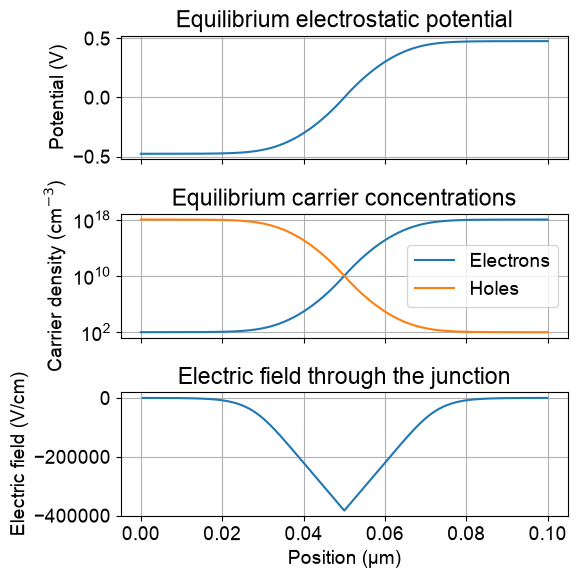

In [55]:
potential = np.asarray(
    get_node_model_values(
        device=device,
        region=region,
        name="Potential",
    )
)

electrons = np.asarray(
    get_node_model_values(
        device=device,
        region=region,
        name="Electrons",
    )
)

holes = np.asarray(
    get_node_model_values(
        device=device,
        region=region,
        name="Holes",
    )
)

electric_field = np.asarray(
    get_edge_model_values(
        device=device,
        region=region,
        name="ElectricField",
    )
)

x_edge_um = 0.5 * (x_um[:-1] + x_um[1:])

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

axes[0].plot(x_um, potential)
axes[0].set_ylabel("Potential (V)")
axes[0].set_title("Equilibrium electrostatic potential")
axes[0].grid(True)

axes[1].semilogy(x_um, electrons, label="Electrons")
axes[1].semilogy(x_um, holes, label="Holes")
axes[1].set_ylabel("Carrier density (cm$^{-3}$)")
axes[1].set_title("Equilibrium carrier concentrations")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(x_edge_um, electric_field)
axes[2].set_xlabel("Position (µm)")
axes[2].set_ylabel("Electric field (V/cm)")
axes[2].set_title("Electric field through the junction")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Equilibrium Energy Band Diagram

We now plot the semiconductor energy bands across the diode. The conduction band edge $E_c$ and valence band edge $E_v$ bend with the electrostatic potential, while the Fermi level $E_F$ remains flat at equilibrium.

This plot helps us see how the built-in electric field and the doping profile shape the band structure of the p–n junction before any external bias is applied.

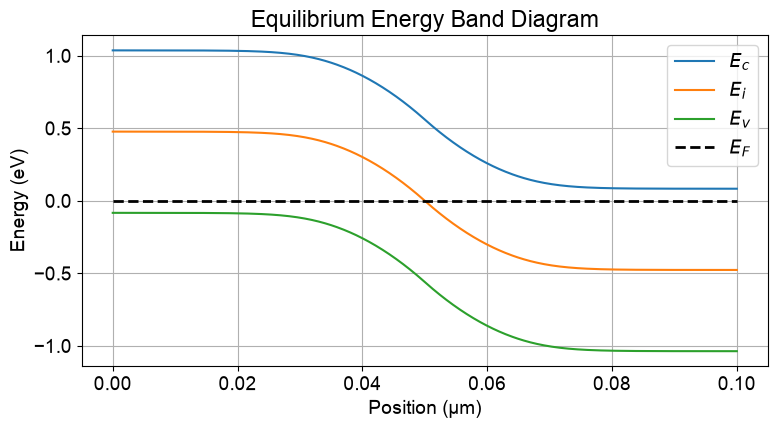

In [56]:
# Equilibrium energy band diagram

from devsim import get_parameter

Eg = 1.12  # approximate silicon band gap in eV
Vt = 0.02585  # thermal voltage at room temperature in eV

potential = np.asarray(
    get_node_model_values(
        device=device,
        region=region,
        name="Potential",
    )
)

electrons = np.asarray(
    get_node_model_values(
        device=device,
        region=region,
        name="Electrons",
    )
)

intrinsic_electrons = np.asarray(
    get_node_model_values(
        device=device,
        region=region,
        name="IntrinsicElectrons",
    )
)

# Prevent numerical issues
eps = 1e-30
electrons = np.clip(electrons, eps, None)
intrinsic_electrons = np.clip(intrinsic_electrons, eps, None)


# ------------------------------------------------------------------
# Electron quasi-Fermi potential
# (constant everywhere at equilibrium)
# ------------------------------------------------------------------

phi_n = Vt * np.log(electrons / intrinsic_electrons)

# Choose the energy reference so that
# EF = 0 eV at the right contact (x = end)

Ef0 = phi_n[-1]
Ef = -phi_n - Ef0


# ------------------------------------------------------------------
# Band edges
#
# Their absolute energy is arbitrary, so we use the same reference
# shift applied to the Fermi level.
# ------------------------------------------------------------------

Ei = -potential - Ef0
Ec = Ei + Eg / 2
Ev = Ei - Eg / 2


plt.figure(figsize=(8, 4.5))

plt.plot(x_um, Ec, label=r"$E_c$")
plt.plot(x_um, Ei, label=r"$E_i$")
plt.plot(x_um, Ev, label=r"$E_v$")
plt.plot(x_um, phi_n, "k--", linewidth=2, label=r"$E_F$")

plt.xlabel("Position (µm)")
plt.ylabel("Energy (eV)")
plt.title("Equilibrium Energy Band Diagram")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Calculating the Terminal Current Density

With the equilibrium solution complete, we can now calculate the **terminal current density** at each contact of the diode. The total current flowing through the device is the sum of two contributions:

- the **electron current**, obtained from the electron continuity equation,
- the **hole current**, obtained from the hole continuity equation.

The function `terminal_current_density()` is created to retrieve these two current components from DEVSIM and adds them together to obtain the **total conventional current density**, measured in A/cm$^2$.

Finally, we evaluate the current density at both the top and bottom contacts. At equilibrium, these values should be essentially zero because there is no external voltage applied and no net flow of charge through the device. Any small non-zero value is simply due to the finite numerical accuracy of the solver.

In [33]:
# --- helper to read terminal current density ---
def terminal_current_density(contact):
    jn = get_contact_current(
        device=device,
        contact=contact,
        equation="ElectronContinuityEquation",
    )
    jp = get_contact_current(
        device=device,
        contact=contact,
        equation="HoleContinuityEquation",
    )
    return jn + jp

j_top = terminal_current_density("top")
j_bottom = terminal_current_density("bot")

print("Top-contact current density:", j_top, "A/cm^2")
print("Bottom-contact current density:", j_bottom, "A/cm^2")

Top-contact current density: -2.1558854434500012e-09 A/cm^2
Bottom-contact current density: -4.7046820549940125e-08 A/cm^2


### Generating the Dark Current–Voltage (J–V) Characteristic

Having established the equilibrium solution, we now investigate how the diode responds when an **external voltage** is applied across its terminals. This is known as a **DC bias sweep**, and it is one of the most common analyses performed in semiconductor device simulation.

We first identify the voltage parameters associated with the two electrical contacts. The bottom contact is fixed at **0 V**, making it the reference terminal (ground), while the voltage applied to the top contact is varied from **−0.2 V** to **+0.8 V**.

For each applied voltage, DEVSIM solves the complete coupled system of semiconductor equations:

- Poisson's equation, which determines the electrostatic potential,
- the electron continuity equation,
- and the hole continuity equation.

Unlike the equilibrium calculation, these equations are now solved under an externally applied bias. The electric potential, carrier concentrations, and current densities all change in response to the applied voltage, so the simulator must find a new self-consistent solution for every voltage in the sweep.

Physically, the applied voltage modifies the height of the built-in potential barrier at the p–n junction:

- Under **forward bias** (positive voltage), the potential barrier is reduced, allowing electrons and holes to diffuse more easily across the junction. As a result, the current increases exponentially.
- Under **reverse bias** (negative voltage), the potential barrier becomes larger, preventing the majority carriers from crossing the junction. Only a very small reverse saturation current remains.

After each solution converges, we calculate the total current density flowing through the top contact by summing the electron and hole current contributions. These values are stored in the array `dark_current`.

Finally, we plot the current density as a function of the applied voltage to produce the **dark J–V characteristic** of the diode. This curve is called the *dark* characteristic because no optical generation of carriers is included in the simulation. It therefore represents the intrinsic electrical behaviour of the p–n junction and forms the foundation for understanding the operation of solar cells, LEDs, and many other semiconductor devices.

number of equations 1395
Iteration: 0
  Device: "SiliconSolarCell"	RelError: 2.59397e+03	AbsError: 4.16597e+17
    Region: "Silicon"	RelError: 2.59397e+03	AbsError: 4.16597e+17
      Equation: "ElectronContinuityEquation"	RelError: 9.99000e+02	AbsError: 2.08220e+17
      Equation: "HoleContinuityEquation"	RelError: 1.52035e+03	AbsError: 2.08377e+17
      Equation: "PotentialEquation"	RelError: 7.46177e+01	AbsError: 5.60955e-02
Iteration: 1
  Device: "SiliconSolarCell"	RelError: 1.21951e+02	AbsError: 1.05778e+17
    Region: "Silicon"	RelError: 1.21951e+02	AbsError: 1.05778e+17
      Equation: "ElectronContinuityEquation"	RelError: 9.98846e-01	AbsError: 5.41296e+16
      Equation: "HoleContinuityEquation"	RelError: 9.98813e-01	AbsError: 5.16487e+16
      Equation: "PotentialEquation"	RelError: 1.19954e+02	AbsError: 4.87025e-02
Iteration: 2
  Device: "SiliconSolarCell"	RelError: 2.03024e+03	AbsError: 2.40408e+16
    Region: "Silicon"	RelError: 2.03024e+03	AbsError: 2.40408e+16
      Equat

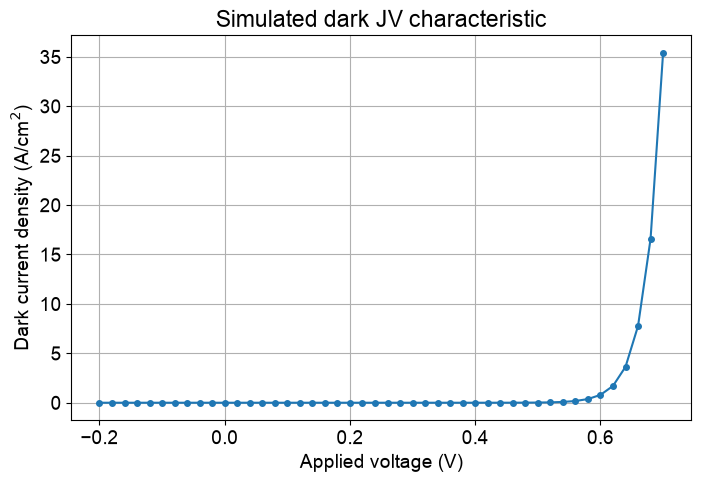

In [34]:
top_bias_name = simple_physics.GetContactBiasName("top")
bottom_bias_name = simple_physics.GetContactBiasName("bot")

devsim.set_parameter(name="debug_level", value="info")

set_parameter(
    device=device,
    name=bottom_bias_name,
    value=0.0,
)
voltages = np.arange(-0.2, 0.71, 0.02)

dark_current = []

for voltage in voltages:
    set_parameter(
        device=device,
        name=top_bias_name,
        value=float(voltage),
    )

    solve(
        type="dc",
        absolute_error=1e10,
        relative_error=1e-8,
        maximum_iterations=50,
        info=False,
    )

    current = terminal_current_density( "top")
    dark_current.append(current)

dark_current = np.asarray(dark_current)

plt.figure(figsize=(8, 5))
plt.plot(voltages, dark_current,'-o', markersize=4, label="Simulated dark JV")

plt.xlabel("Applied voltage (V)")
plt.ylabel("Dark current density (A/cm$^2$)")
plt.title("Simulated dark JV characteristic")
plt.grid(True)
plt.show()

### Energy Band Diagram Under Forward Bias

We now plot the band structure after applying a forward bias of $0.2$ V. In this convention, the electrostatic potential sets the vertical bending of the bands, and the left contact is used as the zero-energy reference.

Because the device is out of equilibrium, the electron and hole populations are described by separate quasi-Fermi levels, $E_{Fn}$ and $E_{Fp}$. Their separation shows how the applied bias drives carrier injection through the junction and lowers the barrier for current flow.

number of equations 1395
Iteration: 0
  Device: "SiliconSolarCell"	RelError: 3.13123e-15	AbsError: 2.30344e+02
    Region: "Silicon"	RelError: 3.13123e-15	AbsError: 2.30344e+02
      Equation: "ElectronContinuityEquation"	RelError: 9.57458e-16	AbsError: 6.34878e+01
      Equation: "HoleContinuityEquation"	RelError: 2.05666e-15	AbsError: 1.66856e+02
      Equation: "PotentialEquation"	RelError: 1.17121e-16	AbsError: 2.96056e-17


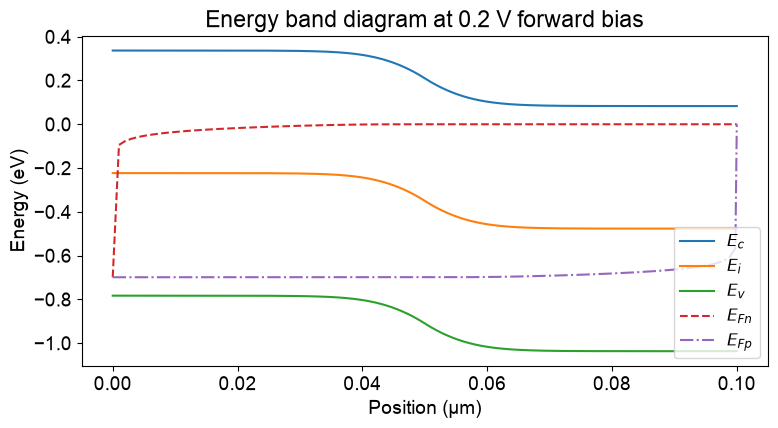

In [60]:
# Energy band diagram at 0.2 V forward bias

from devsim import get_parameter

voltage = 0.7
set_parameter(device=device, name=top_bias_name, value=voltage)
set_parameter(device=device, name=bottom_bias_name, value=0.0)

solve(
    type="dc",
    absolute_error=1e3,
    relative_error=1e-9,
    maximum_iterations=300,
)

x_cm = np.asarray(get_node_model_values(device=device, region=region, name="x"))
x_um = 1e4 * x_cm

potential = np.asarray(get_node_model_values(device=device, region=region, name="Potential"))
electrons = np.asarray(get_node_model_values(device=device, region=region, name="Electrons"))
holes = np.asarray(get_node_model_values(device=device, region=region, name="Holes"))
intrinsic_electrons = np.asarray(
    get_node_model_values(device=device, region=region, name="IntrinsicElectrons")
)
intrinsic_holes = np.asarray(
    get_node_model_values(device=device, region=region, name="IntrinsicHoles")
)

Eg = 1.12    # silicon band gap, eV
Vt = 0.02585 # thermal voltage, eV

eps = 1e-30
electrons = np.clip(electrons, eps, None)
holes = np.clip(holes, eps, None)
intrinsic_electrons = np.clip(intrinsic_electrons, eps, None)
intrinsic_holes = np.clip(intrinsic_holes, eps, None)

# Quasi-Fermi potentials in DEVSIM's convention
phi_n = -Vt * np.log(electrons / intrinsic_electrons)
phi_p =  Vt * np.log(holes / intrinsic_holes)

# Use the left contact as the zero-energy reference
Eref = phi_n[-1] # the reference is set to the right contact, which is at 0 V

# Energy bands referred to that same reference
Ei = -potential - Eref
Ec = Ei + Eg / 2
Ev = Ei - Eg / 2

# Quasi-Fermi levels, shifted to the same reference
Efn = -phi_n - Eref
Efp = -phi_p - Eref

plt.figure(figsize=(8, 4.5))
plt.plot(x_um, Ec, label=r"$E_c$")
plt.plot(x_um, Ei, label=r"$E_i$")
plt.plot(x_um, Ev, label=r"$E_v$")
plt.plot(x_um, Efn, "--", label=r"$E_{Fn}$")
plt.plot(x_um, Efp, "-.", label=r"$E_{Fp}$")
plt.xlabel("Position (µm)")
plt.ylabel("Energy (eV)")
plt.title("Energy band diagram at 0.2 V forward bias")
plt.grid(False)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()

### Adding Optical Generation and Generating the Illuminated J–V Curve

We now extend the drift-diffusion model to represent an illuminated diode by adding a **photogeneration source** to the carrier continuity equations. Under illumination, absorbed photons create electron-hole pairs throughout the semiconductor, producing carriers even when no external current is injected.

The continuity equations solved previously are

$$
\nabla \cdot \mathbf{J}_n
=
q\left(R-G\right),
$$

$$
\nabla \cdot \mathbf{J}_p
=
-q\left(R-G\right),
$$

where

- $\mathbf{J}_n$ and $\mathbf{J}_p$ are the electron and hole current densities,
- $R$ is the carrier recombination rate, and
- $G$ is the carrier generation rate.

In the dark, the generation term is zero,

$$
G = 0,
$$

so only recombination contributes to the source terms. To model illumination, we introduce a constant photogeneration rate,

$$
\boxed{G = G_{\mathrm{photo}},}
$$

which represents the number of electron-hole pairs created per unit volume per second.

In DEVSIM, this is accomplished by replacing the default source terms with

$$
\boxed{\texttt{ElectronGeneration} = +q\,G_{\mathrm{photo}}}
$$

and

$$
\boxed{\texttt{HoleGeneration} = -q\,G_{\mathrm{photo}}.}
$$

These two terms are equal in magnitude and opposite in sign because every absorbed photon generates **one electron and one hole**. Consequently, charge is conserved while both carrier populations increase simultaneously.

After introducing these generation terms, we solve the coupled Poisson, electron continuity, and hole continuity equations again to obtain the steady-state illuminated solution. We then perform another voltage sweep by increasing the voltage applied to the top (p-type) contact while keeping the bottom (n-type) contact grounded.

For each applied voltage, the terminal current density is calculated and plotted to produce the illuminated J–V characteristic. Compared with the dark diode, illumination shifts the current-voltage curve downward by the photocurrent, producing a finite short-circuit current at zero bias and, at sufficiently high voltages, an open-circuit voltage where the net current becomes zero.

Replacing Node Model ElectronGeneration in region Silicon of material Si
Replacing Node Model HoleGeneration in region Silicon of material Si
number of equations 1395
Iteration: 0
  Device: "SiliconSolarCell"	RelError: 1.99917e+00	AbsError: 8.20871e+08
    Region: "Silicon"	RelError: 1.99917e+00	AbsError: 8.20871e+08
      Equation: "ElectronContinuityEquation"	RelError: 9.99447e-01	AbsError: 4.29130e+08
      Equation: "HoleContinuityEquation"	RelError: 9.99722e-01	AbsError: 3.91741e+08
      Equation: "PotentialEquation"	RelError: 8.75787e-08	AbsError: 9.86482e-11
Iteration: 1
  Device: "SiliconSolarCell"	RelError: 1.38467e-09	AbsError: 4.49731e+02
    Region: "Silicon"	RelError: 1.38467e-09	AbsError: 4.49731e+02
      Equation: "ElectronContinuityEquation"	RelError: 7.16923e-10	AbsError: 2.44682e+02
      Equation: "HoleContinuityEquation"	RelError: 6.67736e-10	AbsError: 2.05049e+02
      Equation: "PotentialEquation"	RelError: 9.46206e-15	AbsError: 3.44586e-17
number of equations 1

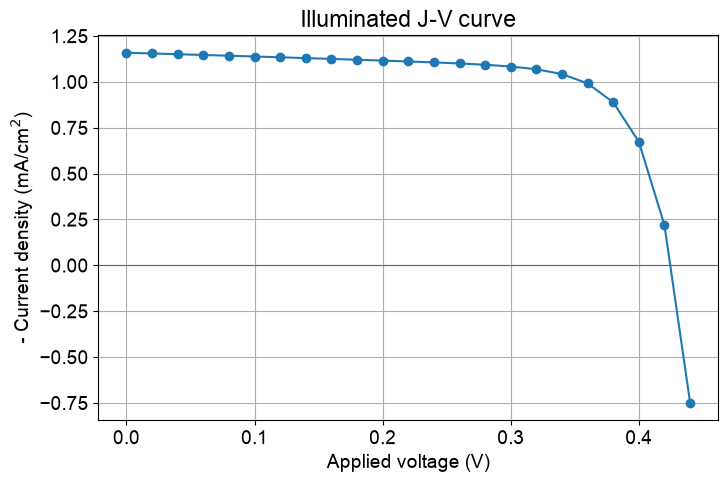

In [13]:
from devsim.python_packages.model_create import CreateNodeModel

q = 1.602176634e-19

# Fixed uniform photogeneration rate in the absorber
# Units: cm^-3 s^-1
G_photo = 1.0e21

# Replace the default SRH-based source terms with a constant generation source.
# Signs are chosen to create electron-hole pairs:
#   electrons get +q*G_photo
#   holes get -q*G_photo
CreateNodeModel(device, region, "ElectronGeneration", f"{q}*{G_photo}")
CreateNodeModel(device, region, "HoleGeneration", f"-{q}*{G_photo}")

# Now solve the coupled Poisson + electron continuity + hole continuity 
# system for the illuminated case. 
# The solution will be the same as the dark case, 
# except that the source terms are now non-zero.

solve(
    type="dc",
    absolute_error=1e10,
    relative_error=1e-8,
    maximum_iterations=50,
)

# --- bias sweep ---

top_bias = simple_physics.GetContactBiasName("top")
bot_bias = simple_physics.GetContactBiasName("bot")

set_parameter(device=device, name=bot_bias, value=0.0)

voltages = np.arange(0.0, 0.51, 0.02)
j_light = []

for v in voltages:
    set_parameter(device=device, name=top_bias, value=float(v))

    solve(
        type="dc",
        absolute_error=1e10,
        relative_error=1e-8,
        maximum_iterations=50,

    )

    # choose the sign convention you want for plotting
    current_density = -terminal_current_density("top")
    j_light.append(current_density)

    if current_density < 0:
        break

j_light = np.asarray(j_light)

plt.figure(figsize=(8, 5))
plt.plot(voltages[:len(j_light)], 1e3 * j_light,'-o')
plt.axhline(0, linewidth=0.8)
plt.xlabel("Applied voltage (V)")
plt.ylabel("- Current density (mA/cm$^2$)")
plt.title("Illuminated J-V curve")
plt.grid(True)
plt.show()


### Evaluating Solar Cell Performance

The illuminated J–V curve contains all the information needed to evaluate the performance of a solar cell. From this curve, we can determine several important figures of merit that describe how effectively the device converts incident light into electrical power.

The electrical power density delivered by the solar cell at each operating voltage is

$$
P(V)=V\,J(V),
$$

where $V$ is the applied voltage and $J(V)$ is the corresponding current density. Multiplying the voltage by the current density produces the power density, measured in W/cm$^2$. Plotting this quantity as a function of voltage gives the **power curve**, whose maximum corresponds to the optimum operating point of the device.

#### Short-Circuit Current Density ($J_{SC}$)

The **short-circuit current density** is the current delivered when the external terminals are shorted together, so that

$$
V=0.
$$

At this operating point,

$$
J_{SC}=J(0).
$$

Physically, $J_{SC}$ measures how many photogenerated carriers are successfully collected by the junction before they recombine. It depends primarily on the optical absorption, carrier lifetimes, diffusion lengths, and the efficiency with which carriers are extracted by the built-in electric field.

#### Open-Circuit Voltage ($V_{OC}$)

The **open-circuit voltage** is the voltage developed across the solar cell when no external current is allowed to flow. Mathematically,

$$
J(V_{OC})=0.
$$

At open circuit, photogenerated carriers continue to be created, but instead of flowing through an external circuit they accumulate inside the device. This carrier accumulation separates the electron and hole quasi-Fermi levels, producing the photovoltage that opposes the built-in electric field. The value of $V_{OC}$ is therefore determined by the balance between photogeneration and recombination and represents the maximum voltage the solar cell can produce.

Since the simulated voltage points are discrete, the code determines $V_{OC}$ by locating where the current changes sign and performing a linear interpolation between the two neighboring bias points.

#### Maximum Power Point (MPP)

Although the solar cell can produce both voltage and current, it cannot maximize both simultaneously. The useful operating point is the **maximum power point (MPP)**, where the product of voltage and current reaches its largest value,

$$
P_{MPP}=V_{MPP}J_{MPP}.
$$

At this point,

- $V_{MPP}$ is the operating voltage,
- $J_{MPP}$ is the corresponding current density, and
- $P_{MPP}$ is the maximum electrical power density that can be extracted from the device.

This is the operating condition that practical photovoltaic systems attempt to maintain using **maximum power point tracking (MPPT)** electronics.

#### Fill Factor (FF)

The **fill factor** measures how closely the illuminated J–V curve approaches the ideal rectangular shape. It is defined as

$$
FF=\frac{V_{MPP}J_{MPP}}
{V_{OC}J_{SC}}.
$$

The denominator,

$$
V_{OC}J_{SC},
$$

represents the area of the rectangle bounded by the open-circuit voltage and the short-circuit current density, while the numerator is the actual maximum power delivered by the device.

An ideal solar cell would have a fill factor close to one. In real devices, recombination, series resistance, shunt leakage, and non-ideal transport reduce the fill factor by causing the J–V curve to become more rounded.

#### Conversion Efficiency

The overall performance of a solar cell is measured by its **power conversion efficiency**, which is the fraction of the incident optical power converted into useful electrical power,

$$
\eta=
\frac{P_{MPP}}
{P_{in}}
\times100\%.
$$

For standard one-sun testing conditions (AM1.5G), the incident optical power density is conventionally taken as

$$
P_{in}=100\ \mathrm{mW/cm^2}.
$$

The efficiency therefore combines the effects of the short-circuit current, open-circuit voltage, and fill factor into a single figure of merit,

$$
\eta=
\frac{J_{SC}V_{OC}FF}
{P_{in}}
\times100\%.
$$

Increasing any one of these three quantities generally improves the efficiency, although they are often coupled through the underlying semiconductor physics. For example, increasing carrier lifetime may improve both $J_{SC}$ and $V_{OC}$, while excessive series resistance primarily reduces the fill factor.

Finally, the calculated quantities are summarized in a table containing the short-circuit current density, open-circuit voltage, maximum power point coordinates, maximum output power, fill factor, and conversion efficiency. Together, these parameters provide a comprehensive assessment of the photovoltaic performance of the simulated solar cell.

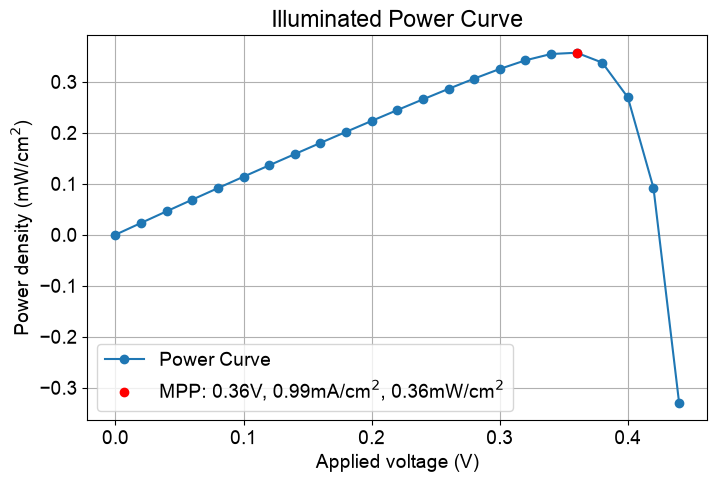

   Property         Value
        Jsc  1.16 mA/cm^2
        Voc       0.425 V
      V_mpp       0.360 V
      J_mpp 0.992 mA/cm^2
      P_mpp 0.357 mW/cm^2
Fill Factor         0.726
 Efficiency        0.36 %


In [14]:
# Ensure voltages and j_light have the same length after the break in the loop
v_curve = voltages[:len(j_light)]
j_curve = np.asarray(j_light)

# Calculate Power Curve (P = V * J)
power_curve = v_curve * j_curve

# 1. Jsc (Short-circuit current density): Current at 0V
Jsc = j_curve[0]

# 2. Voc (Open-circuit voltage): Voltage at which current is 0
# Find where j_curve crosses zero (from positive to negative)
zero_cross_idx = np.where(np.diff(np.sign(j_curve)))[0]
if zero_cross_idx.size > 0:
    idx1 = zero_cross_idx[0]
    idx2 = idx1 + 1
    V1, V2 = v_curve[idx1], v_curve[idx2]
    J1, J2 = j_curve[idx1], j_curve[idx2]
    # Linear interpolation to find Voc
    Voc = V1 - J1 * (V2 - V1) / (J2 - J1)
else:
    Voc = np.nan # No zero crossing found

# 3. MPP (Maximum Power Point)
mpp_index = np.argmax(power_curve)
P_mpp = power_curve[mpp_index]
V_mpp = v_curve[mpp_index]
J_mpp = j_curve[mpp_index]

# 4. Fill Factor (FF)
FF = P_mpp / (Voc * Jsc) if Voc != 0 and Jsc != 0 else np.nan

# 5. Efficiency
# Assuming standard incident power density for AM1.5G of 100 mW/cm^2 (0.1 W/cm^2)
P_in = 0.1 # W/cm^2
efficiency = (P_mpp / P_in) * 100 if P_in != 0 else np.nan

# Plot Power Curve
plt.figure(figsize=(8, 5))
plt.plot(v_curve, 1e3 * power_curve, '-o', label='Power Curve')
plt.plot(V_mpp, 1e3 * P_mpp, 'ro', label=f'MPP: {V_mpp:.2f}V, {1e3 * J_mpp:.2f}mA/cm$^2$, {1e3 * P_mpp:.2f}mW/cm$^2$')
plt.xlabel("Applied voltage (V)")
plt.ylabel("Power density (mW/cm$^2$)")
plt.title("Illuminated Power Curve")
plt.grid(True)
plt.legend()
plt.show()

# Display Data Table
properties = {
    'Property': ['Jsc', 'Voc', 'V_mpp', 'J_mpp', 'P_mpp', 'Fill Factor', 'Efficiency'],
    'Value': [
        f'{1e3 * Jsc:.2f} mA/cm^2',
        f'{Voc:.3f} V',
        f'{V_mpp:.3f} V',
        f'{1e3 * J_mpp:.3f} mA/cm^2',
        f'{1e3 * P_mpp:.3f} mW/cm^2',
        f'{FF:.3f}',
        f'{efficiency:.2f} %'
    ]
}
df = pd.DataFrame(properties)
print(df.to_string(index=False))
